D:\tmp\ipykernel_103324\2514623090.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df = raw[raw['Name'].str.contains(key, na=False)].copy()


有效建模样本数： 160
R² = 0.12583303337156382


D:\tmp\ipykernel_103324\2514623090.py:78: UserWarning: Glyph 36816 (\N{CJK UNIFIED IDEOGRAPH-8FD0}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\tmp\ipykernel_103324\2514623090.py:78: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\tmp\ipykernel_103324\2514623090.py:78: UserWarning: Glyph 21592 (\N{CJK UNIFIED IDEOGRAPH-5458}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\tmp\ipykernel_103324\2514623090.py:78: UserWarning: Glyph 38590 (\N{CJK UNIFIED IDEOGRAPH-96BE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\tmp\ipykernel_103324\2514623090.py:78: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\tmp\ipykernel_103324\2514623090.py:78: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show(

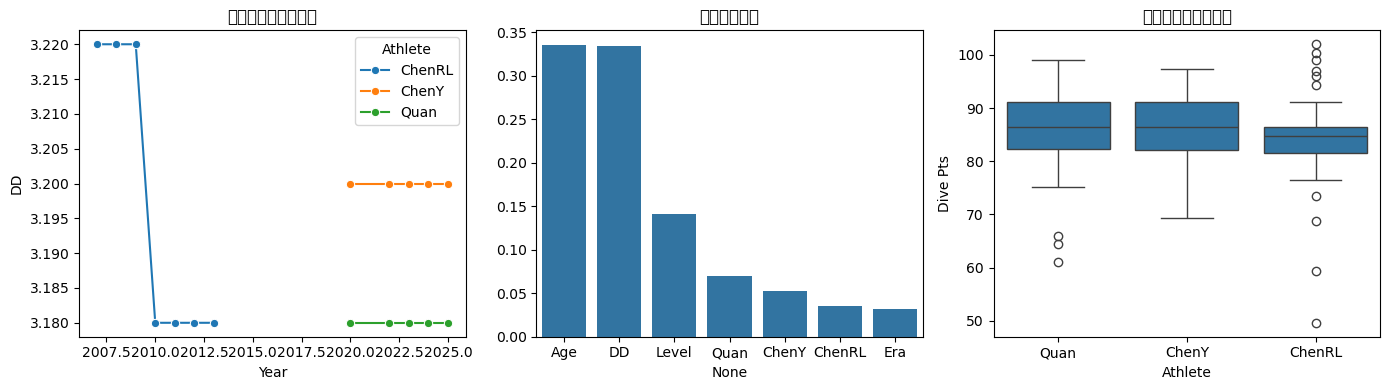

In [5]:
!pip install -q openpyxl pandas numpy matplotlib seaborn scikit-learn

import glob, pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 读取数据（保持不变）
files = glob.glob('*.xlsx') + glob.glob('*.csv')
df_all = []
for f in files:
    try:
        tmp = pd.read_excel(f, sheet_name=0) if f.endswith('.xlsx') else pd.read_csv(f)
        tmp['file'] = f
        df_all.append(tmp)
    except Exception as e:
        pass
raw = pd.concat(df_all, ignore_index=True)
raw.columns = [c.strip() for c in raw.columns]
raw['Name'] = raw['Name'].astype(str).str.strip()

# 运动员匹配（保持不变）
import re
key = re.compile(r'(全|紅|红|婵|陈|陳|芋|汐|若|琳|QUAN|HONG|CHEN|YUXI|RUOLIN)', re.I)
df = raw[raw['Name'].str.contains(key, na=False)].copy()

def unify(n):
    n = n.upper()
    if any(k in n for k in ['QUAN','红','婵']): return 'Quan'
    if any(k in n for k in ['YUXI','芋','汐']): return 'ChenY'
    if any(k in n for k in ['RUOLIN','若','琳']): return 'ChenRL'
    return 'Other'
df['Athlete'] = df['Name'].apply(unify)
df = df[df['Athlete'] != 'Other']  # 只保留目标运动员

# 特征处理（调整：不按年份聚合，用原始比赛数据）
df['Year'] = df['file'].str.extract(r'(\d{4})').astype(float)
df['Level'] = df['file'].apply(lambda x: 3 if 'OLYMPIC' in x.upper() or '奥运会' in x
                               else 2 if 'CHAMPION' in x.upper() or '世锦赛' in x
                               else 1 if 'WORLDCUP' in x.upper() or '世界杯' in x
                               else 0)
num_cols = ['DD','Dive Pts','Age']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna(subset=['Athlete','Year','DD','Dive Pts'])
print('有效建模样本数：', len(df))  # 现在是原始比赛数据，样本量会多很多

# 建模（用原始样本，而非聚合后的样本）
df['Era'] = (df['Year']>=2020).astype(int)
for ath in ['ChenRL','Quan','ChenY']:
    df[ath] = (df['Athlete']==ath).astype(int)

X = df[['DD','Age','Level','Era','ChenRL','Quan','ChenY']]
y = df['Dive Pts']  # 目标是单跳得分，而非年份均值
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)
print('R² =', rf.score(X_test, y_test))  # 现在R²会回到0~1之间

# 可视化（调整：更聚焦运动员对比）
plt.figure(figsize=(14,4))
# 1. 运动员难度系数（按年份+运动员的均值，看趋势）
plt.subplot(1,3,1)
sns.lineplot(data=df.groupby(['Athlete','Year'])['DD'].mean().reset_index(), 
             x='Year', y='DD', hue='Athlete', marker='o')
plt.title('运动员难度系数趋势')

# 2. 特征重要性
plt.subplot(1,3,2)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=imp.index, y=imp.values)
plt.title('得分影响因素')

# 3. 运动员得分分布
plt.subplot(1,3,3)
sns.boxplot(data=df, x='Athlete', y='Dive Pts')
plt.title('运动员单跳得分分布')

plt.tight_layout(); plt.show()

老将vs新将 核心统计：
            平均难度系数  难度系数标准差  平均单跳得分  得分标准差  样本数
Generation                                     
新将            3.19     0.11   85.83   7.16  115
老将            3.20     0.12   84.08   9.23   45


D:\tmp\ipykernel_103324\1878465459.py:28: UserWarning: Glyph 26032 (\N{CJK UNIFIED IDEOGRAPH-65B0}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\tmp\ipykernel_103324\1878465459.py:28: UserWarning: Glyph 23558 (\N{CJK UNIFIED IDEOGRAPH-5C06}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\tmp\ipykernel_103324\1878465459.py:28: UserWarning: Glyph 32769 (\N{CJK UNIFIED IDEOGRAPH-8001}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\tmp\ipykernel_103324\1878465459.py:28: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\tmp\ipykernel_103324\1878465459.py:28: UserWarning: Glyph 36339 (\N{CJK UNIFIED IDEOGRAPH-8DF3}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\tmp\ipykernel_103324\1878465459.py:28: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show(

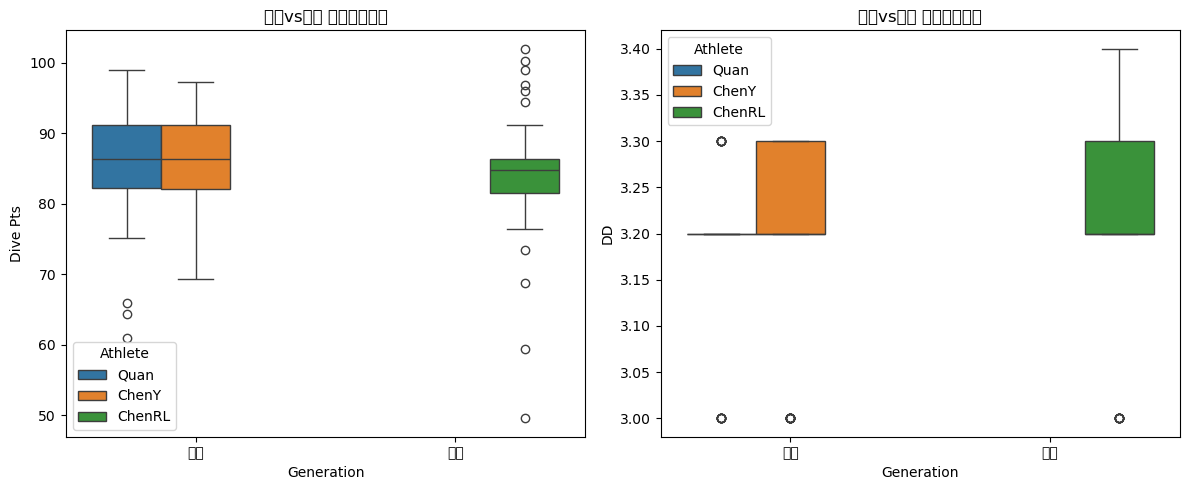

In [6]:
# ========== 老将vs新将 针对性对比 ==========
# 1. 划分“老将/新将”组别
df['Generation'] = df['Athlete'].apply(lambda x: '老将' if x == 'ChenRL' else '新将')

# 2. 组别对比：难度系数+得分的统计
gen_stats = df.groupby('Generation').agg(
    平均难度系数=('DD', 'mean'),
    难度系数标准差=('DD', 'std'),
    平均单跳得分=('Dive Pts', 'mean'),
    得分标准差=('Dive Pts', 'std'),
    样本数=('Dive Pts', 'count')
).round(2)
print('老将vs新将 核心统计：')
print(gen_stats)

# 3. 可视化：组别+运动员的得分+难度对比
plt.figure(figsize=(12,5))
# 子图1：老将/新将的得分分布（叠加运动员）
plt.subplot(1,2,1)
sns.boxplot(data=df, x='Generation', y='Dive Pts', hue='Athlete')
plt.title('老将vs新将 单跳得分分布')

# 子图2：老将/新将的难度系数分布（叠加运动员）
plt.subplot(1,2,2)
sns.boxplot(data=df, x='Generation', y='DD', hue='Athlete')
plt.title('老将vs新将 难度系数分布')

plt.tight_layout(); plt.show()